# Summary

## 1. Imports

In [95]:
import matplotlib.pyplot as plt
import numpy as np
import skimage

## 2. Images

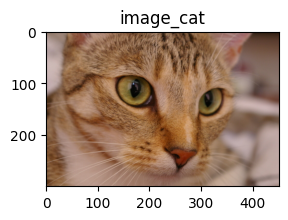

In [96]:
img_cat: np.ndarray = skimage.data.cat()
fig, (ax0) = plt.subplots(nrows=1, ncols=1, figsize=(3, 3))
ax0.set_title("image_cat")
ax0.imshow(img_cat)

### 2.1 Structure
- An image is represented as a 2D-Array with a color value in every cell: [High:Width:Color]
- High x Width x Color as RGB or RGBA (with transparency)

#### 2.1.1 3x3 Grayscale Image
- Default structure:
  - Image: <kbd>row[column[pixel]]</kbd>
  - Python: <kbd>list[list[int]]</kbd>
  - Numpy: <kbd>np.ndarray[np.ndarray[np.uint8]]</kbd>

In [97]:
# Pixel intensity range: 0 (darkest) to 255 (brightest)
value = 128
gray_image = [
                [value, value, value], # First Row, 3 gray pixels
                [value, value, value], # Second Row, 3 gray pixels
                [value, value, value]  # Third Row, 3 gray pixels
             ]

#### 2.1.2 3x3 RGB Image (Red, Green, Blue)
- Default structure:
  - Image: <kbd>row[column[pixel[red, green, blue]]]</kbd>
  - Python: <kbd>list[list[list[int, int, int]]]</kbd>
  - Numpy: <kbd>np.ndarray[np.ndarray[np.ndarray[np.uint8]]]</kbd>

In [98]:
# Pixel intensity range: 0 (darkest) to 255 (brightest)
red = 171
green = 29
blue = 66
rgb_image = [
              [[red, green, blue], [red, green, blue], [red, green, blue]], # First Row, 3 Pixels @ RGB
              [[red, green, blue], [red, green, blue], [red, green, blue]], # Second Row, 3 Pixels @ RGB
              [[red, green, blue], [red, green, blue], [red, green, blue]]  # Third Row, 3 Pixels @ RGB
            ]

#### 2.1.3 3x3 RGBA Image (Red, Green, Blue, Alpha)
- Default structure:
  - Image: <kbd>row[column[pixel[red, green, blue, alpha]]]</kbd>
  - Python: <kbd>list[list[list[int, int, int, int]]]</kbd>
  - Numpy: <kbd>np.ndarray[np.ndarray[np.ndarray[np.uint8]]]</kbd>

In [99]:
# Transparency value (alpha): 0 = invisible, 255 = fully visible
alpha = 128
rgba_image  = [
                [[red, green, blue, alpha], [red, green, blue, alpha], [red, green, blue, alpha]], # First Row, 3 Pixels @ RGB + 1 Alpha for transparency
                [[red, green, blue, alpha], [red, green, blue, alpha], [red, green, blue, alpha]], # Second Row, 3 Pixels @ RGB + 1 Alpha for transparency
                [[red, green, blue, alpha], [red, green, blue, alpha], [red, green, blue, alpha]]  # Third Row, 3 Pixels @ RGB + 1 Alpha for transparency
              ]

#### 2.1.4 Grayscale vs. RGB vs. RGBA

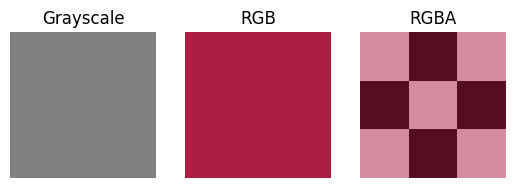

In [100]:
bw_mosaic = [[255, 0, 255], [0, 255, 0], [255, 0, 255]]

fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3)
ax0.set_title("Grayscale")
ax0.axis("off")
ax0.imshow(gray_image, cmap="gray", vmin=0, vmax=255)
ax1.set_title("RGB")
ax1.axis("off")
ax1.imshow(rgb_image, vmin=0, vmax=255)
ax2.set_title("RGBA")
ax2.axis("off")
ax2.imshow(bw_mosaic, cmap="gray", vmin=0, vmax=255)
ax2.imshow(rgba_image, vmin=0, vmax=255)

### 2.2 Image slicing
#### 2.2.1 Rules
- Structure for an image: <kbd>image[row, column, pixel]</kbd>
  - **Row** (height)
  - **Column** (width)
  - **Pixel** (Gray, RGB, RGBA)
- Each dimension can be further selected with <kbd>[beginn:end:step]</kbd>
  - **Beginn**: First element (inclusive)
  - **End**: Last Element (exclusive)
  - **Step**: Defines direction and interval
- E.g <kbd>image[row_begin:row_end:row_step, col_begin:col_end:col_step, px_begin:px_end:px_step]</kbd>

#### 2.2.2 Examples
Rows
- <kbd>image[0:200]</kbd> or <kbd>image[:200]</kbd> (Select row 0 to row 199)
- <kbd>image[:200:2]</kbd> (Select _**every 2nd row**_ from row 0 to row 199)
- <kbd>image[200:0:-1]</kbd> (Select row 200 to row 1 in _**reverse**_ order.)
- <kbd>image[200:0:-2]</kbd> (Select _**every 2nd row**_ from row 200 to row 01 in _**reverse**_ order.)

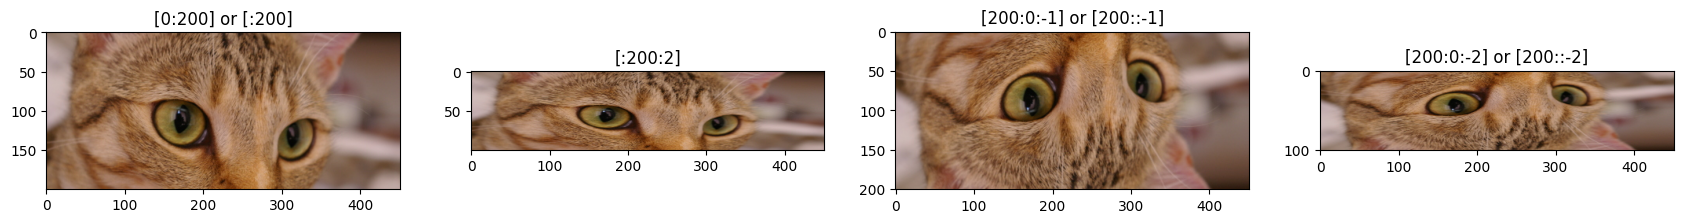

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(21, 9))
axes[0].set_title("[0:200] or [:200]")
axes[0].imshow(img_cat[:200])
axes[1].set_title("[:200:2]")
axes[1].imshow(img_cat[:200:2])
axes[2].set_title("[200:0:-1] or [200::-1]")
axes[2].imshow(img_cat[200::-1])
axes[3].set_title("[200:0:-2] or [200::-2]")
axes[3].imshow(img_cat[200::-2])

Columns
- <kbd>image[:, 100:350]</kbd> (From _**all**_ rows, select column 100 to column 349)
- <kbd>image[:, 100:350:2]</kbd> (From _**all**_ rows, select _**every 2nd column**_ from column 100 to column 349)
- <kbd>image[:, 350:100:-1]</kbd> (From _**all**_ rows, select column 350 to column 101 in _**reverse**_ order.)
- <kbd>image[:, 350:100:-2]</kbd> (From _**all**_ rows, select _**every 2nd column**_ from column 350 to column 101 in _**reverse**_ order.)

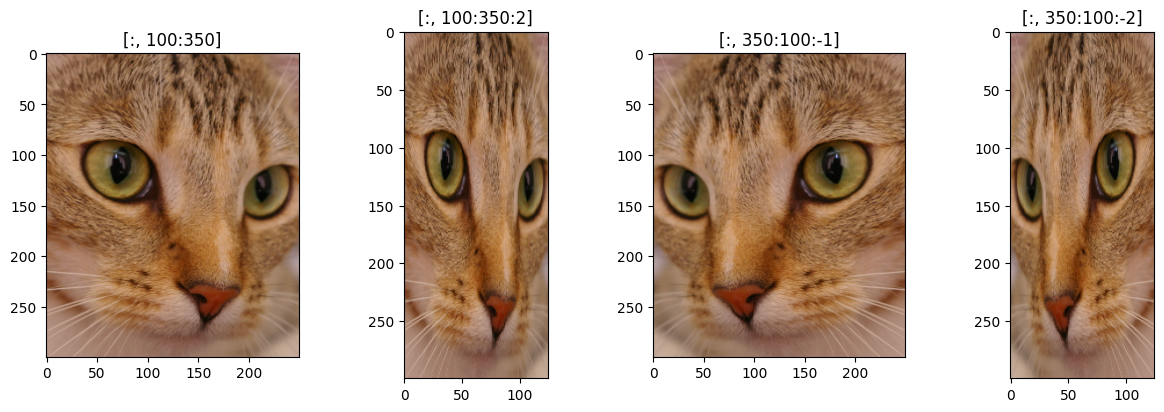

In [102]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 4.5))
axes[0].set_title("[:, 100:350]")
axes[0].imshow(img_cat[:, 100:350])
axes[1].set_title("[:, 100:350:2]")
axes[1].imshow(img_cat[:, 100:350:2])
axes[2].set_title("[:, 350:100:-1]")
axes[2].imshow(img_cat[:, 350:100:-1])
axes[3].set_title("[:, 350:100:-2]")
axes[3].imshow(img_cat[:, 350:100:-2])

Pixel
- <kbd>image[:, :, :]</kbd> (From _**all**_ rows and _**all**_ columns, select _**all**_ channels 🌈)
- <kbd>image[:, :, 0]</kbd> (From _**all**_ rows and _**all**_ columns, select the _**Red**_ channel 🔴)
- <kbd>image[:, :, 1]</kbd> (From _**all**_ rows and _**all**_ columns, select the _**Green**_ channel 🟢)
- <kbd>image[:, :, 2]</kbd> (From _**all**_ rows and _**all**_ columns, select the _**Blue**_ channel 🔵)

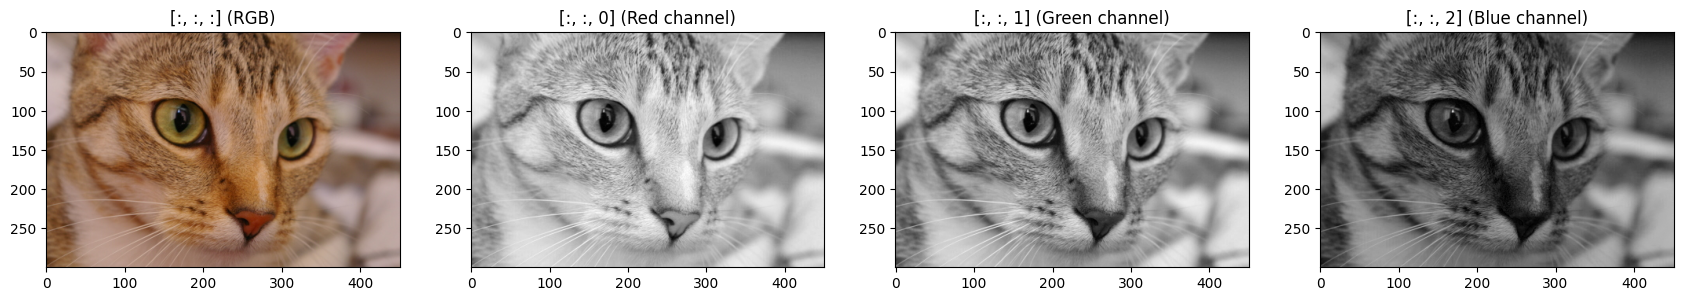

In [103]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(21, 9))
axes[0].set_title("[:, :, :] (RGB)")
axes[0].imshow(img_cat[:, :, :], cmap="gray")
axes[1].set_title("[:, :, 0] (Red channel)")
axes[1].imshow(img_cat[:, :, 0], cmap="gray")
axes[2].set_title("[:, :, 1] (Green channel)")
axes[2].imshow(img_cat[:, :, 1], cmap="gray")
axes[3].set_title("[:, :, 2] (Blue channel)")
axes[3].imshow(img_cat[:, :, 2], cmap="gray")